<a href="https://colab.research.google.com/github/Amos-THX/Automated-Portfolio-Aggregation-Workflow/blob/main/Portfolio_Aggregator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Generate Dummy Transaction Data

To simulate portfolio activity, we'll create a DataFrame with dummy buy and sell transactions for AAPL and GOOG shares. This data will include `Date`, `Ticker`, `Transaction_Type`, `Quantity`, and `Price`.

In [8]:
import pandas as pd
from datetime import date

# Create dummy transaction data
transactions_data = {
    'Date': pd.to_datetime(['2022-12-30',
        '2023-01-05', '2023-01-10', '2023-01-15', '2023-02-01', '2023-02-10',
        '2023-02-15', '2023-03-01', '2023-03-05', '2023-03-10', '2023-03-15'
    ]),
    'Ticker': ['CASH',
        'AAPL', 'AAPL', 'GOOG', 'AAPL', 'GOOG',
        'AAPL', 'GOOG', 'AAPL', 'GOOG', 'AAPL'
    ],
    'Transaction_Type': ['Cash_Deposit',
        'Buy', 'Buy', 'Buy', 'Buy', 'Buy',
        'Sell', 'Buy', 'Sell', 'Sell', 'Buy'
    ],
        'CCY': ['USD',
        'USD', 'USD', 'USD', 'USD', 'USD',
        'USD', 'USD', 'USD', 'USD', 'USD'
    ],
    'Quantity': [10000,
        10, 5, 8, 12, 6,
        3, 10, 2, 4, 7
    ],
    'Price': [1,
        170.00, 175.50, 95.00, 180.25, 100.10,
        178.00, 105.00, 185.00, 102.50, 182.75
    ]
}

transactions_df = pd.DataFrame(transactions_data)

# Calculate the 'Amount' column based on cash flow (positive for inflow, negative for outflow)
transactions_df['Amount'] = transactions_df.apply(
    lambda row:
        row['Quantity'] * row['Price'] if row['Transaction_Type'] in ['Sell', 'Cash_Deposit']
        else (-1 * row['Quantity'] * row['Price'] if row['Transaction_Type'] in ['Buy', 'Cash_Withdrawl']
        else 0),
    axis=1
)

# Display the first few rows of the dummy transaction data including the new 'Amount' column
display(transactions_df.head(10))

,Date,Ticker,Transaction_Type,CCY,Quantity,Price,Amount
0,2022-12-30,CASH,Cash_Deposit,USD,10000,1.00,10000.0
1,2023-01-05,AAPL,Buy,USD,10,170.00,-1700.0
2,2023-01-10,AAPL,Buy,USD,5,175.50,-877.5
3,2023-01-15,GOOG,Buy,USD,8,95.00,-760.0
4,2023-02-01,AAPL,Buy,USD,12,180.25,-2163.0
5,2023-02-10,GOOG,Buy,USD,6,100.10,-600.6
6,2023-02-15,AAPL,Sell,USD,3,178.00,534.0
7,2023-03-01,GOOG,Buy,USD,10,105.00,-1050.0
8,2023-03-05,AAPL,Sell,USD,2,185.00,370.0
9,2023-03-10,GOOG,Sell,USD,4,102.50,410.0


### Fetch Historical Market Data

To calculate the portfolio's value and performance, we need historical market prices for the assets (AAPL and GOOG) involved in the transactions. We will use the `yfinance` library to download this data. The date range for the historical data will span from the earliest transaction date to the latest.

In [9]:
# Install yfinance if not already installed
%pip install yfinance

In [10]:
import yfinance as yf

# Get the list of unique tickers from the transactions (excluding 'CASH')
tickers = transactions_df[transactions_df['Ticker'] != 'CASH']['Ticker'].unique().tolist()

# Determine the date range for fetching historical data
start_date = transactions_df['Date'].min()
# Add a buffer of a few days to ensure we capture prices before the first transaction if needed
start_date = start_date - pd.Timedelta(days=5)
end_date = date.today() # Last day = latest day

print(f"Fetching historical data for {tickers} from {start_date.strftime('%Y-%m-%d')} to {end_date.strftime('%Y-%m-%d')}")

# Download historical data
historical_prices_df = yf.download(tickers, start=start_date, end=end_date)

# We are interested in the 'Close' price for each ticker
# The dataframe will have a MultiIndex column for (Attribute, Ticker)
# Let's clean it up to have Ticker as the top level column

# Select only the 'Close' prices
close_prices = historical_prices_df['Close']

# Display the first few rows of the historical close prices
display(close_prices.head())

/tmp/ipykernel_36244/3451653754.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  historical_prices_df = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  2 of 2 completed

Fetching historical data for ['AAPL', 'GOOG'] from 2022-12-25 to 2026-05-26


Ticker,AAPL,GOOG
Date,,
2022-12-27,127.859932,87.213989
2022-12-28,123.936546,85.755943
2022-12-29,127.446960,88.225670
2022-12-30,127.761589,88.007477
2023-01-03,122.982704,88.969559


### Calculate Daily Holdings and Cash Balance

Now, we'll process the transaction data and historical prices to determine the daily quantity of each asset held and the daily cash balance. This step is crucial for valuing the portfolio over time.

In [11]:
# 1. Prepare Daily Price Data
# Ensure close_prices index is a DatetimeIndex and sort it
close_prices.index = pd.to_datetime(close_prices.index)
close_prices = close_prices.sort_index()

# Create a full date range covering all transactions and prices
min_date = transactions_df['Date'].min()
max_date = close_prices.index.max()
all_dates = pd.date_range(start=min_date, end=max_date, freq='B')

# Reindex close_prices to fill in missing dates and forward-fill values
daily_prices = close_prices.reindex(all_dates).ffill()

# Initialize holdings and cash DataFrames
holdings = pd.DataFrame(0.0, index=all_dates, columns=transactions_df['Ticker'].unique())
cash_balance = pd.Series(0.0, index=all_dates)

# Sort transactions by date
transactions_df = transactions_df.sort_values(by='Date')

# Process transactions
for index, row in transactions_df.iterrows():
    date = row['Date']
    ticker = row['Ticker']
    trans_type = row['Transaction_Type']
    quantity = row['Quantity']
    amount = row['Amount'] # Amount now directly represents the cash flow (positive for inflow, negative for outflow)

    # Apply changes from the transaction date onwards
    if ticker == 'CASH':
        cash_balance.loc[date:] += amount # Add amount for Cash_Deposit (positive) or Cash_Withdrawl (negative)
    else:
        # Update holdings
        if trans_type == 'Buy':
            holdings.loc[date:, ticker] += quantity
        elif trans_type == 'Sell':
            holdings.loc[date:, ticker] -= quantity

        # In both Buy and Sell cases, add the amount to cash balance (amount is negative for buy, positive for sell)
        cash_balance.loc[date:] += amount


# Remove 'CASH' column from holdings as it's tracked separately
if 'CASH' in holdings.columns:
    holdings = holdings.drop(columns='CASH')


# Display the first few rows of daily holdings and cash balance
print("Daily Holdings (first 5 rows):")
display(holdings.head())
print("\nDaily Cash Balance (first 5 rows):")
display(cash_balance.head())

# Create a mapping for Ticker to CCY
ticker_ccy_map = transactions_df[['Ticker', 'CCY']].drop_duplicates().set_index('Ticker')['CCY'].to_dict()

# Melt the holdings DataFrame to long format (Date, Ticker, Quantity)
daily_holdings_melted = holdings.reset_index().melt(id_vars='index', var_name='Ticker', value_name='Quantity')
daily_holdings_melted = daily_holdings_melted.rename(columns={'index': 'Date'})

# Filter out rows where Quantity is 0 (no holdings for that ticker on that date)
daily_holdings_melted = daily_holdings_melted[daily_holdings_melted['Quantity'] > 0].copy()

# Merge with daily_prices to get the Latest_Price
# Rename the index of daily_prices for merging
daily_prices_renamed = daily_prices.stack().reset_index()
daily_prices_renamed.columns = ['Date', 'Ticker', 'Latest_Price']

# Merge daily_holdings_melted with daily_prices_renamed
daily_portfolio_holdings = pd.merge(
    daily_holdings_melted,
    daily_prices_renamed,
    on=['Date', 'Ticker'],
    how='left'
)

# Add CCY column using the mapping
daily_portfolio_holdings['CCY'] = daily_portfolio_holdings['Ticker'].map(ticker_ccy_map)

# Calculate Value
daily_portfolio_holdings['Value'] = daily_portfolio_holdings['Quantity'] * daily_portfolio_holdings['Latest_Price']

# Reorder columns as requested: Date, Ticker, CCY, Latest_Price, Value
daily_portfolio_holdings = daily_portfolio_holdings[['Date', 'Ticker', 'CCY', 'Latest_Price', 'Quantity', 'Value']]

print("\nDaily Portfolio Holdings (first 5 rows):")
display(daily_portfolio_holdings.head())

# Add cash to daily_portfolio_holdings
cash_df = pd.DataFrame({
    'Date': cash_balance.index,
    'Ticker': 'CASH',
    'CCY': ticker_ccy_map.get('CASH', 'USD'), # Ensure 'USD' if 'CASH' not in map (though it should be)
    'Latest_Price': 1.0,
    'Quantity': cash_balance.values, # Quantity of cash is its balance
    'Value': cash_balance.values      # Value of cash is its balance * 1
})

daily_portfolio_holdings = pd.concat([daily_portfolio_holdings, cash_df], ignore_index=True)

# Sort by Date and Ticker for better readability
daily_portfolio_holdings = daily_portfolio_holdings.sort_values(by=['Date', 'Ticker']).reset_index(drop=True)

print("\nDaily Portfolio Holdings (including Cash, first 5 rows):")
display(daily_portfolio_holdings.head(100))

Daily Holdings (first 5 rows):


,AAPL,GOOG
2022-12-30,0.0,0.0
2023-01-02,0.0,0.0
2023-01-03,0.0,0.0
2023-01-04,0.0,0.0
2023-01-05,10.0,0.0



Daily Cash Balance (first 5 rows):


,0
2022-12-30,10000.0
2023-01-02,10000.0
2023-01-03,10000.0
2023-01-04,10000.0
2023-01-05,8300.0



Daily Portfolio Holdings (first 5 rows):


,Date,Ticker,CCY,Latest_Price,Quantity,Value
0,2023-01-05,AAPL,USD,122.933540,10.0,1229.335403
1,2023-01-06,AAPL,USD,127.456795,10.0,1274.567947
2,2023-01-09,AAPL,USD,127.977943,10.0,1279.779434
3,2023-01-10,AAPL,USD,128.548248,15.0,1928.223724
4,2023-01-11,AAPL,USD,131.262238,15.0,1968.933563



Daily Portfolio Holdings (including Cash, first 5 rows):


,Date,Ticker,CCY,Latest_Price,Quantity,Value
0,2022-12-30,CASH,USD,1.000000,10000.0,10000.000000
1,2023-01-02,CASH,USD,1.000000,10000.0,10000.000000
2,2023-01-03,CASH,USD,1.000000,10000.0,10000.000000
3,2023-01-04,CASH,USD,1.000000,10000.0,10000.000000
4,2023-01-05,AAPL,USD,122.933540,10.0,1229.335403
...,...,...,...,...,...,...
95,2023-02-20,GOOG,USD,93.819740,14.0,1313.476364
96,2023-02-21,AAPL,USD,146.224945,24.0,3509.398682
97,2023-02-21,CASH,USD,1.000000,4432.9,4432.900000
98,2023-02-21,GOOG,USD,91.300423,14.0,1278.205917


In [12]:
# 1. Calculate Daily Total Networth
total_networth = daily_portfolio_holdings.groupby('Date')['Value'].sum().rename('Total Networth')

# 2. Calculate Daily Transfer In/Out Amounts (External Cash Flows)
# Filter transactions for only Cash_Deposit and Cash_Withdrawl
external_cash_flows = transactions_df[
    transactions_df['Transaction_Type'].isin(['Cash_Deposit', 'Cash_Withdrawl'])
].copy()

# Group by date and sum the 'Amount' (already signed correctly for inflow/outflow)
daily_external_cash_flow = external_cash_flows.groupby('Date')['Amount'].sum().rename('Daily External Cash Flow')

# 3. Create performance_df by combining total_networth and daily_external_cash_flow
# Use all_dates (from previous step, which includes all business days) to ensure all dates are covered
performance_df = pd.DataFrame(index=all_dates)
performance_df.index.name = 'Date'

# Reindex and forward fill Total Networth. Fill any leading NaNs with 0 (initial state)
performance_df['Total Networth'] = total_networth.reindex(all_dates).ffill().fillna(0)

# Reindex Daily External Cash Flow. Fill NaNs with 0 (no external cash flow on that day)
performance_df['Daily External Cash Flow'] = daily_external_cash_flow.reindex(all_dates).fillna(0)

# 4. Calculate Net Worth at the beginning of the day (shifted Total Networth)
# This represents the portfolio value *before* any transactions or market movements on the current day.
performance_df['Begin Networth'] = performance_df['Total Networth'].shift(1).fillna(0)

# 5. Calculate Net Worth Change (End of Day Networth - Beginning of Day Networth)
performance_df['Networth Change'] = performance_df['Total Networth'] - performance_df['Begin Networth']

# 6. Calculate Profit and Loss
# P&L = Net Worth Change - Daily External Cash Flow
performance_df['Profit/Loss'] = performance_df['Networth Change'] - performance_df['Daily External Cash Flow']

# 7. Calculate Daily Return for Time-Weighted Returns (TWR)
# Formula: (End_Value - Begin_Value - Cash_Flow) / (Begin_Value + Cash_Flow)
# End_Value = Total Networth (end of day)
# Begin_Value = Begin Networth (start of day)
# Cash_Flow = Daily External Cash Flow (during the day)

twr_numerator = performance_df['Total Networth'] - performance_df['Begin Networth'] - performance_df['Daily External Cash Flow']
twr_denominator = performance_df['Begin Networth'] + performance_df['Daily External Cash Flow']

performance_df['Daily Return'] = twr_numerator / twr_denominator

# Handle division by zero for Daily Return
# If the denominator is 0, it means no capital at the beginning of the period plus no external cash flow.
# In such cases, the return is typically undefined. We'll set it to 0 as no return can be generated from zero capital.
performance_df.loc[twr_denominator == 0, 'Daily Return'] = 0

# Fill any remaining NaNs in Daily Return with 0 (e.g., if there's no data for the very first period)
performance_df['Daily Return'] = performance_df['Daily Return'].fillna(0)

# 8. Calculate Cumulative Time-Weighted Returns (TWR)
# This is calculated by geometrically linking the daily returns: (1 + R1) * (1 + R2) * ... * (1 + Rn) - 1
performance_df['Cumulative TWR'] = (1 + performance_df['Daily Return']).cumprod() - 1

# Display the resulting performance DataFrame
print("Performance DataFrame (first 10 rows):")
display(performance_df.head(10))

print("\nPerformance DataFrame (last 10 rows):")
display(performance_df.tail(10))

Performance DataFrame (first 10 rows):


,Total Networth,Daily External Cash Flow,Begin Networth,Networth Change,Profit/Loss,Daily Return,Cumulative TWR
Date,,,,,,,
2022-12-30,10000.000000,10000.0,0.000000,10000.000000,0.000000,0.000000,0.000000
2023-01-02,10000.000000,0.0,10000.000000,0.000000,0.000000,0.000000,0.000000
2023-01-03,10000.000000,0.0,10000.000000,0.000000,0.000000,0.000000,0.000000
2023-01-04,10000.000000,0.0,10000.000000,0.000000,0.000000,0.000000,0.000000
2023-01-05,9529.335403,0.0,10000.000000,-470.664597,-470.664597,-0.047066,-0.047066
2023-01-06,9574.567947,0.0,9529.335403,45.232544,45.232544,0.004747,-0.042543
2023-01-09,9579.779434,0.0,9574.567947,5.211487,5.211487,0.000544,-0.042022
2023-01-10,9350.723724,0.0,9579.779434,-229.055710,-229.055710,-0.023910,-0.064928
2023-01-11,9391.433563,0.0,9350.723724,40.709839,40.709839,0.004354,-0.060857



Performance DataFrame (last 10 rows):


,Total Networth,Daily External Cash Flow,Begin Networth,Networth Change,Profit/Loss,Daily Return,Cumulative TWR
Date,,,,,,,
2026-05-11,19106.769568,0.0,19323.100287,-216.330719,-216.330719,-0.011195,0.910677
2026-05-12,19109.249792,0.0,19106.769568,2.480225,2.480225,0.000130,0.910925
2026-05-13,19531.680029,0.0,19109.249792,422.430237,422.430237,0.022106,0.953168
2026-05-14,19475.140021,0.0,19531.680029,-56.540009,-56.540009,-0.002895,0.947514
2026-05-15,19456.720465,0.0,19475.140021,-18.419556,-18.419556,-0.000946,0.945672
2026-05-18,19383.209601,0.0,19456.720465,-73.510864,-73.510864,-0.003778,0.938321
2026-05-19,19251.779913,0.0,19383.209601,-131.429688,-131.429688,-0.006781,0.925178
2026-05-20,19346.899878,0.0,19251.779913,95.119965,95.119965,0.004941,0.934690
2026-05-21,19397.759741,0.0,19346.899878,50.859863,50.859863,0.002629,0.939776


In [13]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# --- 1. Performance Chart (Cumulative TWR) ---
# plt.figure(figsize=(12, 6))
# plt.plot(performance_df.index, performance_df['Cumulative TWR'], label='Cumulative TWR')
# plt.title('Portfolio Time-Weighted Return (TWR) Since Inception')
# plt.xlabel('Date')
# plt.ylabel('Cumulative TWR')
# plt.grid(True)
# plt.axhline(0, color='red', linestyle='--', linewidth=0.7) # Add a zero line
# plt.legend()

# # Format y-axis as percentage
# plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# plt.show()

# --- 2. Calculate Performance Metrics ---

# Total Performance (Since Inception)
total_performance_since_inception = performance_df['Cumulative TWR'].iloc[-1]

# Annualized Performance
first_date = performance_df.index[0]
last_date = performance_df.index[-1]
num_days = (last_date - first_date).days

annualized_performance = 0.0
if num_days > 0:
    num_years = num_days / 365.25
    if num_years >= 1: # Only annualize if at least one year has passed
        # Handle case where 1 + total_performance_since_inception is negative or zero
        base = 1 + total_performance_since_inception
        if base > 0:
            annualized_performance = (base**(1 / num_years)) - 1
        else:
            annualized_performance = float('nan') # Cannot compute if base is non-positive

# Helper function to get the closest date in the index
def get_closest_date(target_date, df_index):
    if target_date <= df_index[0]: # If target is before or at the first date, use first date
        return df_index[0]
    if target_date >= df_index[-1]: # If target is after or at the last date, use last date
        return df_index[-1]
    return df_index[df_index.get_indexer([target_date], method='pad')[0]]

# Rolling Period Performance
performance_periods = {
    '1 Month': pd.DateOffset(months=1),
    '3 Months': pd.DateOffset(months=3),
    '6 Months': pd.DateOffset(months=6),
    '1 Year': pd.DateOffset(years=1)
}

rolling_performance = {}
for period_name, offset in performance_periods.items():
    start_date_target = last_date - offset
    actual_start_date = get_closest_date(start_date_target, performance_df.index)

    # Get cumulative TWR at start and end of the period
    cum_twr_at_start = performance_df.loc[actual_start_date, 'Cumulative TWR']
    cum_twr_at_end = performance_df.loc[last_date, 'Cumulative TWR']

    # Calculate period return: (1 + R_end) / (1 + R_start) - 1
    # Ensure 1 + R_start is not zero to prevent division by zero
    if (1 + cum_twr_at_start) != 0:
        period_return = (1 + cum_twr_at_end) / (1 + cum_twr_at_start) - 1
    else:
        period_return = float('nan') # Undefined return if starting value is zero

    rolling_performance[period_name] = period_return

# Display Metrics
print(f"\nTotal Performance (Since Inception): {total_performance_since_inception:.2%}")

if not pd.isna(annualized_performance):
    print(f"Annualized Performance: {annualized_performance:.2%}")
else:
    print("Annualized Performance: N/A (Cannot compute)")

print("\nPerformance for Selected Periods:")
for period, perf in rolling_performance.items():
    if not pd.isna(perf):
        print(f"  {period}: {perf:.2%}")
    else:
        print(f"  {period}: N/A (Cannot compute)")


Total Performance (Since Inception): 94.27%
Annualized Performance: 21.62%

Performance for Selected Periods:
  1 Month: 10.68%
  3 Months: 15.34%
  6 Months: 16.14%
  1 Year: 60.19%


## Portfolio Performance Report

### Cumulative Time-Weighted Return (TWR) Since Inception

The chart below illustrates the growth of your portfolio's cumulative time-weighted return since its inception. This provides a visual overview of your investment performance over the entire period.


### Performance Metrics Summary

Here's a detailed summary of your portfolio's performance across various timeframes, calculated using Time-Weighted Returns.

*   **Total Performance (Since Inception):** {{total_performance_since_inception:.2%}}
*   **Annualized Performance:** {{annualized_performance:.2% if not pd.isna(annualized_performance) else 'N/A'}}

#### Performance for Selected Periods:
*   **1 Month:** {{rolling_performance['1 Month']:.2% if not pd.isna(rolling_performance['1 Month']) else 'N/A'}}
*   **3 Months:** {{rolling_performance['3 Months']:.2% if not pd.isna(rolling_performance['3 Months']) else 'N/A'}}
*   **6 Months:** {{rolling_performance['6 Months']:.2% if not pd.isna(rolling_performance['6 Months']) else 'N/A'}}
*   **1 Year:** {{rolling_performance['1 Year']:.2% if not pd.isna(rolling_performance['1 Year']) else 'N/A'}}


/tmp/ipykernel_36244/2204828513.py:53: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark_df = yf.download(benchmark_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_36244/2204828513.py:285: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


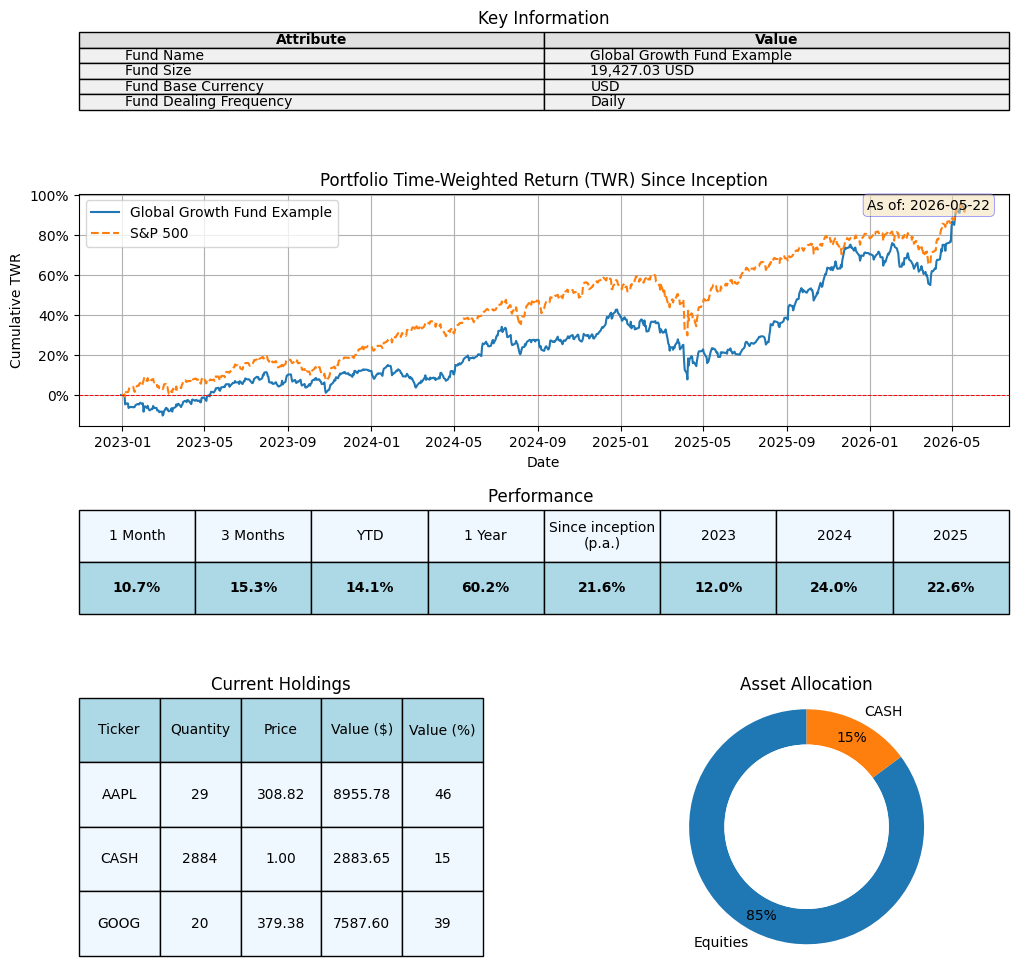

In [14]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
import pandas as pd
from datetime import date
import yfinance as yf

# --- Prepare Data for Report ---

# Get the latest date
latest_date = performance_df.index[-1]

# Get current holdings (for the latest date)
current_holdings = daily_portfolio_holdings[daily_portfolio_holdings['Date'] == latest_date].copy()
current_holdings['Value'] = current_holdings['Value'].round(2)

# Calculate Asset Allocation
total_current_value = current_holdings['Value'].sum()
current_holdings['Allocation'] = (current_holdings['Value'] / total_current_value) * 100

# Prepare current_holdings_display for table, applying desired formatting
current_holdings_display = current_holdings[['Ticker', 'Quantity', 'Latest_Price', 'Value', 'Allocation']].copy()
current_holdings_display.columns = ['Ticker', 'Quantity', 'Price', 'Value ($)', 'Value (%)']
current_holdings_display['Quantity'] = current_holdings_display['Quantity'].apply(lambda x: f'{round(x):.0f}')
current_holdings_display['Price'] = current_holdings_display['Price'].apply(lambda x: f'{x:.2f}')
current_holdings_display['Value ($)'] = current_holdings_display['Value ($)'].apply(lambda x: f'{x:.2f}')
current_holdings_display['Value (%)'] = current_holdings_display['Value (%)'].apply(lambda x: f'{round(x):.0f}')


# --- Prepare Data for Asset Allocation Pie Chart ---
pie_chart_data = current_holdings[['Ticker', 'Allocation']].copy()

# Group stock tickers into 'Equities'
if 'CASH' in pie_chart_data['Ticker'].values:
    equity_allocations_df = pie_chart_data[pie_chart_data['Ticker'] != 'CASH']

    if not equity_allocations_df.empty:
        total_equity_allocation = equity_allocations_df['Allocation'].sum()
        equities_entry = pd.DataFrame([{'Ticker': 'Equities', 'Allocation': total_equity_allocation}])
        pie_chart_data_final = pd.concat([equities_entry, pie_chart_data[pie_chart_data['Ticker'] == 'CASH']], ignore_index=True)
    else: # Only cash, no equities
        pie_chart_data_final = pie_chart_data[pie_chart_data['Ticker'] == 'CASH'].copy()
else: # No cash, all equities or nothing
    if not pie_chart_data.empty:
        total_equity_allocation = pie_chart_data['Allocation'].sum()
        pie_chart_data_final = pd.DataFrame([{'Ticker': 'Equities', 'Allocation': total_equity_allocation}])
    else: # No holdings at all
        pie_chart_data_final = pd.DataFrame(columns=['Ticker', 'Allocation'])

# --- Fetch and Calculate Benchmark Data (e.g., S&P 500 Index) ---
benchmark_ticker = '^GSPC' # S&P 500 index
benchmark_name = 'S&P 500' # Display name for the benchmark
benchmark_df = yf.download(benchmark_ticker, start=start_date, end=end_date)
benchmark_prices = benchmark_df['Close']

# Ensure benchmark_prices index is a DatetimeIndex and sort it
benchmark_prices.index = pd.to_datetime(benchmark_prices.index)
benchmark_prices = benchmark_prices.sort_index()

# Reindex benchmark_prices to fill in missing dates and forward-fill values
daily_benchmark_prices = benchmark_prices.reindex(all_dates).ffill()

# Calculate daily returns for the benchmark
daily_benchmark_returns = daily_benchmark_prices.pct_change().fillna(0)

# Calculate cumulative returns for the benchmark
cumulative_benchmark_twr = (1 + daily_benchmark_returns).cumprod() - 1

# --- Performance Metrics Calculation ---
# Helper function to get the closest date in the index (re-defining for self-contained cell)
def get_closest_date(target_date, df_index):
    if target_date <= df_index[0]:
        return df_index[0]
    if target_date >= df_index[-1]:
        return df_index[-1]
    return df_index[df_index.get_indexer([target_date], method='pad')[0]]

# Initialize a list to hold performance metrics for tabular display
performance_metrics_for_table = []

# Add "Since inception (p.a.)" which is the annualized performance
performance_metrics_for_table.append(['Since inception (p.a.)', annualized_performance])

# YTD Performance
ytd_start_date_target = pd.Timestamp(f'{latest_date.year}-01-01')
actual_ytd_start_date = get_closest_date(ytd_start_date_target, performance_df.index)

cum_twr_at_ytd_start = performance_df.loc[actual_ytd_start_date, 'Cumulative TWR']
cum_twr_at_end_for_ytd = performance_df.loc[latest_date, 'Cumulative TWR']

ytd_performance = 0.0
if (1 + cum_twr_at_ytd_start) != 0:
    ytd_performance = (1 + cum_twr_at_end_for_ytd) / (1 + cum_twr_at_ytd_start) - 1
else:
    ytd_performance = float('nan')
performance_metrics_for_table.append(['YTD', ytd_performance])


# Add yearly performance calculations for past 3 calendar years
current_year = latest_date.year
# Get years dynamically and sort them for consistent display
past_3_years = []
for year_offset in range(1, 4):
    target_year = current_year - year_offset
    past_3_years.append(target_year)
past_3_years.sort() # Ensure ascending order for display (e.g., 2023, 2024, 2025)

for target_year in past_3_years:
    year_start_date_target = pd.Timestamp(f'{target_year}-01-01')
    year_end_date_target = pd.Timestamp(f'{target_year}-12-31')

    actual_year_start_date = get_closest_date(year_start_date_target, performance_df.index)
    actual_year_end_date = get_closest_date(year_end_date_target, performance_df.index)

    yearly_performance = float('nan')
    if actual_year_start_date <= actual_year_end_date:
        cum_twr_at_year_start = performance_df.loc[actual_year_start_date, 'Cumulative TWR']
        cum_twr_at_year_end = performance_df.loc[actual_year_end_date, 'Cumulative TWR']

        if (1 + cum_twr_at_year_start) != 0:
            yearly_performance = (1 + cum_twr_at_year_end) / (1 + cum_twr_at_year_start) - 1
        else:
            yearly_performance = float('nan')

    performance_metrics_for_table.append([f'{target_year}', yearly_performance])


# Add rolling period performance
for period_name, perf_val in rolling_performance.items():
    performance_metrics_for_table.append([period_name, perf_val])

# Convert to DataFrame and format for display
performance_table_df = pd.DataFrame(performance_metrics_for_table, columns=['Metric', 'Return'])
performance_table_df['Return'] = performance_table_df['Return'].apply(lambda x: f'{x:.1%}' if not pd.isna(x) else 'N/A')


# --- Create the Combined Report Figure with GridSpec ---

fig = plt.figure(figsize=(12, 12)) # Adjusted figure size for new row
gs = gridspec.GridSpec(4, 2, figure=fig, height_ratios=[0.3, 0.9, 0.4, 1], wspace=0.3, hspace=0.5) # 4 rows, 2 columns. Increased Key Info, Decreased Performance Table

# --- New Subplot: Key Information Table (top-most row) ---
ax_key_info = fig.add_subplot(gs[0, :]) # First row, spans both columns
ax_key_info.set_title('Key Information', fontsize=12)
ax_key_info.axis('off') # Hide axes for the table

key_info_data = [
    ['Fund Name', 'Global Growth Fund Example'],
    ['Fund Size', f'{total_current_value:,.2f} USD'],
    ['Fund Base Currency', 'USD'],
    ['Fund Dealing Frequency', 'Daily']
]

key_info_table = ax_key_info.table(cellText=key_info_data,
                              colLabels=['Attribute', 'Value'],
                              loc='center',
                              bbox=[0, 0, 1, 1],
                              cellLoc='left',
                              rowLoc='left')

key_info_table.auto_set_font_size(False)
key_info_table.set_fontsize(10) # Adjust font size
key_info_table.scale(1, 1.7) # Increased cell height

# Style the key information table cells
for (row, col), cell in key_info_table.get_celld().items():
    cell.set_facecolor('#f0f0f0') # Grey background
    if row == 0: # Header row
        cell.set_facecolor('#e0e0e0') # Darker grey for header
        cell.set_text_props(weight='bold')


# --- Subplot 1: Cumulative TWR Chart (second row, spans both columns) ---
ax0 = fig.add_subplot(gs[1, :]) # This makes it span across both columns in the second row
ax0.plot(performance_df.index, performance_df['Cumulative TWR'], label='Global Growth Fund Example')
ax0.plot(cumulative_benchmark_twr.index, cumulative_benchmark_twr, label=f'{benchmark_name}', linestyle='--') # Add benchmark
ax0.set_title('Portfolio Time-Weighted Return (TWR) Since Inception')
ax0.set_xlabel('Date')
ax0.set_ylabel('Cumulative TWR')
ax0.grid(True)
ax0.axhline(0, color='red', linestyle='--', linewidth=0.7) # Add a zero line
ax0.legend()
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

# Add latest date to the top right of the TWR chart
ax0.text(0.98, 0.98, f"As of: {latest_date.strftime('%Y-%m-%d')}",
             horizontalalignment='right', verticalalignment='top', transform=ax0.transAxes,
             fontsize=10, bbox=dict(boxstyle="round,pad=0.3", fc="wheat", ec="b", lw=0.5, alpha=0.5))


# --- Subplot 2: Performance Metrics Table (third row, spans both columns) ---
ax_perf_table = fig.add_subplot(gs[2, :]) # This makes it span across both columns in the third row
ax_perf_table.set_title('Performance ', fontsize=12)
ax_perf_table.axis('off') # Hide axes for the table

# Transpose the performance_table_df for horizontal display
perf_table_display = performance_table_df.set_index('Metric').T

# Define the desired column order for the table
desired_column_order = [
    '1 Month', '3 Months', 'YTD', '1 Year', 'Since inception (p.a.)'
] + sorted([str(year) for year in past_3_years]) # Add sorted past 3 years

# Filter and reorder columns based on desired_column_order
# Only include columns that actually exist in perf_table_display
filtered_desired_column_order = [col for col in desired_column_order if col in perf_table_display.columns]
perf_table_display = perf_table_display[filtered_desired_column_order]

# Define a mapping for column labels to introduce newlines for wrapping
label_mapping = {
    'Since inception (p.a.)': 'Since inception\n(p.a.)',
}
display_col_labels = [label_mapping.get(col, col) for col in perf_table_display.columns]


performance_table_obj = ax_perf_table.table(cellText=perf_table_display.values,
                              colLabels=display_col_labels,
                              loc='center',
                              bbox=[0, 0, 1, 1], # Make the table fill the subplot area
                              cellLoc='center',
                              rowLoc='center')

performance_table_obj.auto_set_font_size(False)
performance_table_obj.set_fontsize(10) # Adjust font size
performance_table_obj.scale(1, 1.2) # Decreased cell height

# Style the table cells (header and data row)
for key, cell in performance_table_obj.get_celld().items():
    if key[0] == 0: # This refers to the single data row (index 0)
        cell.set_facecolor('#F0F8FF') # AliceBlue for data row
    else: # This refers to the column headers
        cell.set_facecolor('#ADD8E6') # Light blue for header
        cell.set_text_props(weight='bold')


# --- Subplot 3: Current Holdings Table (bottom left, fourth row) ---
ax1 = fig.add_subplot(gs[3, 0]) # Fourth row, first column
ax1.set_title('Current Holdings')
ax1.axis('off') # Hide axes for the table

# Create the table using plt.table for better formatting
table = ax1.table(cellText=current_holdings_display.values,
                  colLabels=current_holdings_display.columns,
                  loc='center',
                  bbox=[0, 0, 1, 1],
                  cellLoc='center',
                  rowLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5) # Adjust cell height for better spacing

# Add colors to the table
for (row, col), cell in table.get_celld().items():
    if row == 0: # Header row
        cell.set_facecolor('#ADD8E6') # Light blue for header
    else:
        cell.set_facecolor('#F0F8FF') # AliceBlue for data rows

# --- Subplot 4: Asset Allocation Pie Chart (bottom right, fourth row) ---
ax2 = fig.add_subplot(gs[3, 1]) # Fourth row, second column

# Filter out 0 allocation for cleaner pie chart
allocation_data_for_pie_plot = pie_chart_data_final[pie_chart_data_final['Allocation'] > 0]

# Only plot if there's data to show
if not allocation_data_for_pie_plot.empty:
    wedges, texts, autotexts = ax2.pie(allocation_data_for_pie_plot['Allocation'],
                                           labels=allocation_data_for_pie_plot['Ticker'],
                                           autopct=lambda p: f'{p:.0f}%', # 0 decimal places
                                           startangle=90,
                                           pctdistance=0.85,
                                           wedgeprops=dict(width=0.3))
    # Draw a circle at the center to make it a donut chart
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    ax2.add_artist(centre_circle)

    ax2.set_title('Asset Allocation')
    ax2.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
else:
    ax2.set_title('Asset Allocation: No assets to display')
    ax2.text(0.5, 0.5, 'No assets with positive allocation.',
                 horizontalalignment='center', verticalalignment='center', transform=ax2.transAxes)

plt.tight_layout()
plt.savefig('portfolio_performance_report.png') # Save the figure
plt.show()